# Simulation of the 2D Maxwell Equation using Quantum Hamiltonian Simulation

In the present notebook we simulate the **2D Maxwell equations** (TM mode) for a homogeneous medium, employing a quantum Hamiltonian simulation. We work in **CGS** units, where the Maxwell equations take a symmetric form with a single wave speed parameter $c$. Earlier quantum approaches to Maxwell-type wave equations include explicit time-marching schemes [<a href="#ref-costa">1</a>] and variational/quantum-classical solvers [<a href="#ref-suau">2</a>]; here we instead block-encode the spatial operator and evolve it via Hamiltonian simulation.

The transverse-magnetic (TM) mode on a 2-D domain involves three field components, the out-of-plane electric field $E_z$ and the in-plane magnetic field components $H_x$, $H_y$, governed by

$$
\frac{\partial E_z}{\partial t} = c\!\left(\frac{\partial H_y}{\partial x} - \frac{\partial H_x}{\partial y}\right), \qquad
\frac{\partial H_x}{\partial t} = -c\,\frac{\partial E_z}{\partial y}, \qquad
\frac{\partial H_y}{\partial t} = c\,\frac{\partial E_z}{\partial x}.  
$$

Discretizing on a **Yee lattice** [<a href="#ref-yee">3</a>] with spacing $\Delta L$ and using backward ($\nabla^{b}$) and forward ($\nabla^{f}$) finite differences, the system can be written in matrix form as

$$
\frac{d}{dt}\begin{pmatrix} \vec{E}_z \\[4pt] \vec{H}_x \\[4pt] \vec{H}_y \end{pmatrix}
= \frac{c}{\Delta L}\,
\underbrace{\begin{pmatrix}
0 & -\nabla_y^{b} & \nabla_x^{b} \\
-\nabla_y^{f} & 0 & 0 \\
\nabla_x^{f} & 0 & 0
\end{pmatrix}}_{A}
\begin{pmatrix} \vec{E}_z \\[4pt] \vec{H}_x \\[4pt] \vec{H}_y \end{pmatrix}.  \tag{1}
$$

The matrix $A$ is real and anti-symmetric ($A = -A^T$), which makes it anti-Hermitian. Therefore the time-evolution operator $e^{A\,c\,t / \Delta L}$ is unitary. This makes the system a natural fit for quantum Hamiltonian simulation, with $H=iA$.

We enforce **Perfect Electric Conductor (PEC)** boundary conditions on the exterior of the domain and on a rectangular obstacle inside it.

## Implementation with Classiq

We begin by importing the required Python packages.

Importing latest version of Classiq:

In [1]:
!pip install -qq "classiq[qsp]" -U

We begin with two helpers for comparing quantum and classical solutions: phase normalization and a fidelity measure. The remaining utilities — field plotting, state-vector reconstruction, a synthesis/execution wrapper, and the classical reference simulation itself — are introduced later, each where it is first used.

In [2]:
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.linalg

from classiq import *
from classiq.interface.generator.model.preferences.preferences import (
    TranspilationOption,
)

In [3]:
def normalize_phase(data: np.ndarray) -> np.ndarray:
    """
    Normalize the phase of a complex vector so that the maximum amplitude is real and positive.
    This is useful for comparing quantum and classical solutions up to a global phase.
    """
    _max = max(data, key=np.abs)
    return data * (np.abs(_max) / _max)


def fidelity(a: np.ndarray, b: np.ndarray) -> float:
    """
    fidelity of the normalized vectors
    """
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return 0.0
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    return float(abs(np.vdot(a, b)) ** 2)

## Problem Definition

We discretize the domain on an $L \times L$ **Yee lattice**. In this staggered grid the electric field $E_z$ lives at the **vertices** (integer grid points), while the magnetic components $H_x$ and $H_y$ are located at the **edge midpoints**:

- $E_z(i,\,j)$ — grid vertices.
- $H_x(i,\,j+\tfrac{1}{2})$ — midpoints of vertical edges (between consecutive $y$-nodes at fixed $x$).
- $H_y(i+\tfrac{1}{2},\,j)$ — midpoints of horizontal edges (between consecutive $x$-nodes at fixed $y$).


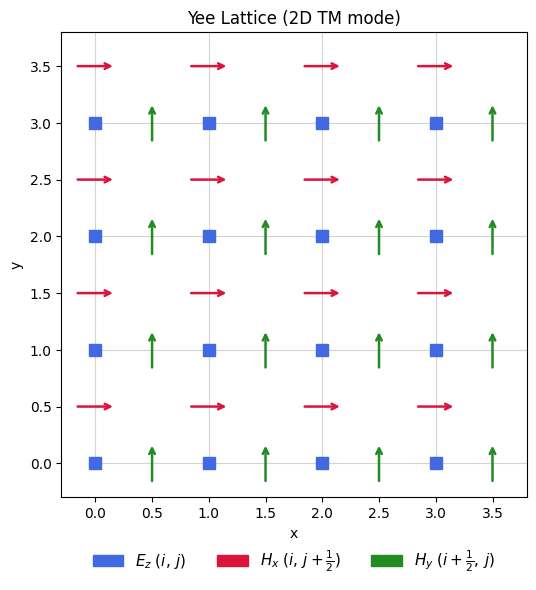

We next set the problem parameters — the grid, the timescale, and the geometry of the system — together with the width and center of the Gaussian pulse we will later use as the initial state.

In [4]:
SIZE = 5  # qubits per spatial axis (square grid of side L = 2**SIZE)
T = 5
c = 1

# grid
L = 2**SIZE

dL = 1 / L

# initial state - gaussian parameters
sigma = 1 / (8 * dL)
mu = L / 8

# geometry - rectangle
middle_x = 0.5
middle_y = 0.5
side_length = 0.5

half_length = side_length / 2
top_x = 1 + int(np.floor((middle_x + half_length) * (L - 2))) + 1
top_y = 1 + int(np.floor((middle_y + half_length) * (L - 2))) + 1
bottom_x = 1 + int(np.ceil((middle_x - half_length) * (L - 2)))
bottom_y = 1 + int(np.ceil((middle_y - half_length) * (L - 2)))

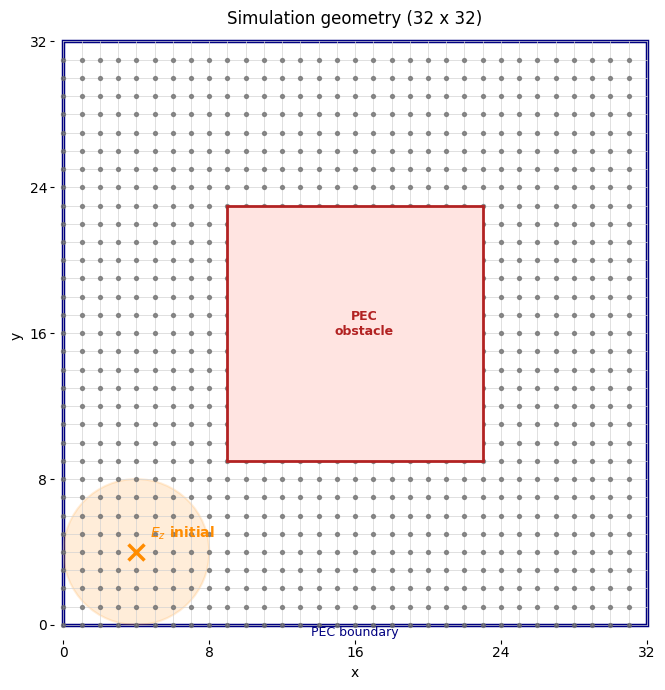

### Quantum Encoding of the Electromagnetic System

We introduce a QStruct to represent the EM field, utilizing two `QNum`s to encode the position (one for the $x$-coordinate and one for $y$), with two further qubits encoding the vector `[Ez, unused, Hx, Hy]` at each coordinate.

In [5]:
class EMState(QStruct):
    x: QNum[SIZE]
    y: QNum[SIZE]
    # the (field, direction) pair indexes the 4-vector [Ez, unused, Hx, Hy]
    direction: QBit  # Hx=0, Hy=1
    field: QBit  # E=0, H=1

### Construction of the Quantum Functions 

#### Gradients

We start by defining the **1D periodic backward and forward gradient** operators on a grid of size $N$.

These come from the **first-order finite-difference** approximation of a derivative. For a function sampled at the grid points $f_i = f(i\,\Delta L)$, the spatial derivative can be estimated by comparing a point to its neighbor, either one step *backward* or one step *forward*:

$$
\left.\frac{\partial f}{\partial x}\right|_i \;\approx\; \frac{f_i - f_{i-1}}{\Delta L} \quad\text{(backward)},
\qquad
\left.\frac{\partial f}{\partial x}\right|_i \;\approx\; \frac{f_{i+1} - f_i}{\Delta L} \quad\text{(forward)},
$$

each accurate to $\mathcal{O}(\Delta L)$. The common $1/\Delta L$ factor is pulled out into the $c/\Delta L$ prefactor of Eq. (1), so the gradient *operators* themselves carry only the dimensionless differences $f_i - f_{i-1}$ and $f_{i+1} - f_i$. Introducing the cyclic shift $S^{+1}$ with $(S^{+1} f)_i = f_{i-1}$ and its inverse $(S^{-1} f)_i = f_{i+1}$, these read $\nabla^{b} = I - S^{+1}$ and $\nabla^{f} = S^{-1} - I$. The periodic (wrap-around) boundary turns the lone off-diagonal corner entry on, making them $N \times N$ circulant matrices:

$$
\nabla^{b} = I - S^{+1} = \begin{pmatrix}
1 & 0 & \cdots & 0 & -1 \\
-1 & 1 & 0 & \cdots & 0 \\
0 & -1 & 1 & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & 0 \\
0 & \cdots & 0 & -1 & 1
\end{pmatrix}, \qquad
\nabla^{f} = S^{-1} - I = \begin{pmatrix}
-1 & 1 & 0 & \cdots & 0 \\
0 & -1 & 1 & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & 0 \\
0 & \cdots & 0 & -1 & 1 \\
1 & 0 & \cdots & 0 & -1
\end{pmatrix},
$$

Note that the backward and forward operators are transposes up to a sign, $\nabla^{f} = -(\nabla^{b})^{\mathsf T}$, making the assembled Maxwell matrix $A$ anti-symmetric. We build the corresponding quantum functions and plot the non-zero components of the backward gradient.

In [6]:
from classiq.qmod.symbolic import pi


@qfunc
def grad_backwards_periodic(r: QNum, block: QBit):
    """
    +1 on the diagonal
    -1 below the diagonal
    """
    lcu(
        coefficients=[0.5, -0.5],
        unitaries=[lambda: None, lambda: inplace_add(1, r)],
        block=block,
    )


@qfunc
def grad_forwards_periodic(r: QNum, block: QBit):
    """
    -1 on the diagonal
    +1 above the diagonal
    """
    invert(grad_backwards_periodic)(r, block)
    phase(pi)

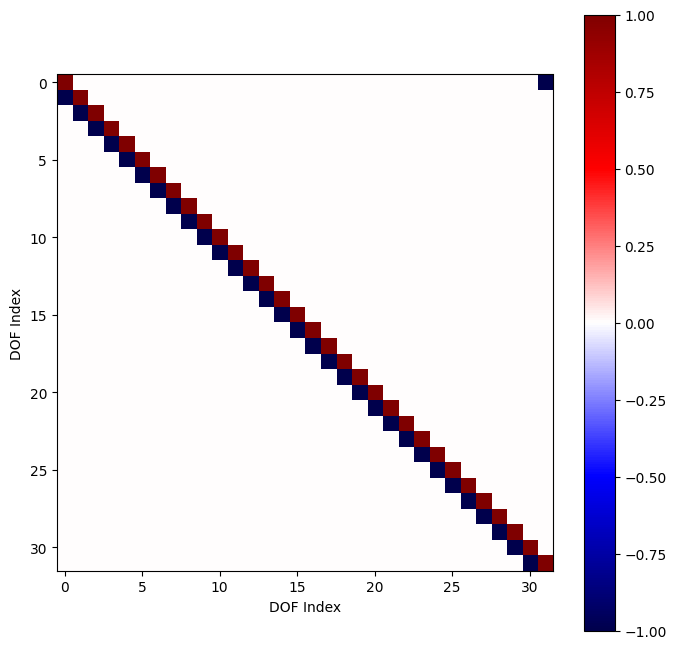

We next assemble the full gradient from the backward and forward gradients.

We build the full matrix as a decomposition into block operators:
$$
A_{E_z,H_x} =
\begin{pmatrix}
0 & 0 & -\nabla_y^{b} & 0 \\
0 & 0 & 0 & 0 \\
-\nabla_y^{f} & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{pmatrix}
\quad
\begin{matrix} \leftarrow E_z \\ \leftarrow \text{(unused)} \\ \leftarrow H_x \\ \leftarrow H_y \end{matrix}
$$

with
$$
A_{E_z,H_y} =
\begin{pmatrix}
0 & 0 & 0 & \nabla_x^{b} \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
\nabla_x^{f} & 0 & 0 & 0
\end{pmatrix}
\quad
\begin{matrix} \leftarrow E_z \\ \leftarrow \text{(unused)} \\ \leftarrow H_x \\ \leftarrow H_y \end{matrix} \tag{2}
$$
and the periodic Maxwell operator is assembled as an **LCU** of the two interactions:

$$
A = A_{E_z,H_x} + A_{E_z,H_y} =
\begin{pmatrix}
0 & 0 & -\nabla_y^{b} & \nabla_x^{b} \\
0 & 0 & 0 & 0 \\
-\nabla_y^{f} & 0 & 0 & 0 \\
\nabla_x^{f} & 0 & 0 & 0
\end{pmatrix}~~.
\quad
$$

To construct the gradient we first introduce a utility quantum function `grad_backwards_forwards_periodic`, which builds a block operator including the backward and forward gradients on the diagonal: 
$$
\begin{pmatrix}
\nabla^{b} & 0 \\
0 & \nabla^{f}\\
\end{pmatrix}~~.
$$

In [7]:
@qfunc
def grad_backwards_forwards_periodic(r: QNum, toggle: QBit, block: QBit) -> None:
    """
    2 blocks (based on the toggle qubit)
    upper left - backwards
    lower right - forwards
    """
    control(
        toggle,
        lambda: grad_forwards_periodic(r, block),  # toggle=1
        lambda: grad_backwards_periodic(r, block),  # toggle=0
    )

We now construct the quantum functions corresponding to $A_{E_z, H_x}$ and $A_{E_z, H_y}$ of Eq. (2), operating on the quantum state $\{E_z, \text{unused}, H_x, H_y \}^T$.

In [8]:
@qfunc
def ez_hx_interaction(em_state: EMState, block: QArray) -> None:
    """
    Block-encode the E_z <-> H_x coupling (the A_{E_z,H_x} block of Eq. (2)).

    Realizes the two coupled updates, with the y-derivative discretized as a
    backward/forward finite difference:
        dt(E_z) += -dy_b(H_x)   # backward gradient on the (E_z, H_x) entry
        dt(H_x) += -dy_f(E_z)   # forward  gradient on the (H_x, E_z) entry
    """
    # swap columns
    em_state.field ^= 1

    # block encode
    grad_backwards_forwards_periodic(em_state.y, em_state.field, block[1:])

    # apply the minus sign to the components
    phase(pi)

    # delete rows 1, 3 (in this case could delete instead the columns, by doing that before the block encoding)
    block[0] ^= em_state.direction


@qfunc
def ez_hy_interaction(em_state: EMState, block: QArray) -> None:
    """
    Block-encode the E_z <-> H_y coupling (the A_{E_z,H_y} block of Eq. (2)).

    Realizes the two coupled updates, with the x-derivative discretized as a
    backward/forward finite difference:
        dt(E_z) += dx_b(H_y)   # backward gradient on the (E_z, H_y) entry
        dt(H_y) += dx_f(E_z)   # forward  gradient on the (H_y, E_z) entry
    """
    # swap columns 0, 3 by doing the following 2 swaps:
    # swap columns 0, 1 and 2, 3
    em_state.direction ^= 1
    # swap columns 0, 2 and 1, 3
    em_state.field ^= 1

    # block encode
    grad_backwards_forwards_periodic(em_state.x, em_state.field, block[1:])

    # delete rows 1, 2
    block[0] ^= em_state.direction ^ em_state.field


@qfunc
def periodic_maxwell_operator(em_state: EMState, block: QArray) -> None:
    """
    Assemble the full periodic evolution operator, without the boundary conditions
    """
    lcu(
        coefficients=[0.5, 0.5],
        unitaries=[
            lambda: ez_hx_interaction(em_state, block[1:]),
            lambda: ez_hy_interaction(em_state, block[1:]),
        ],
        block=block[0],
    )

We impose **Perfect Electric Conductor (PEC)** boundary conditions: on the surface of a perfect conductor the tangential electric field must vanish, so we force $E_z = 0$ on every conducting site — both the outer edge of the domain and the interior rectangular obstacle. Physically this makes the conductor act as a perfect mirror for the wave.

We implement this by *deleting* the corresponding entries of the Maxwell matrix $A$ with a **flag (block) qubit**: whenever the state sits on a site where $E_z$ must vanish, we flip the flag, pushing that amplitude out of the all-zeros block subspace so it no longer contributes to the encoded operator. The flag is applied only to the $E_z$ component (`field == 0` and `direction == 0`); because $H_x, H_y$ are coupled to $E_z$ through the dynamics, their boundary behavior follows implicitly.

Two regions are flagged (see the `@qperm` functions below):

- **Exterior boundary** — since the gradient operators are periodic, fixing the **origin of each axis** ($x = 0$ or $y = 0$) is enough; the opposite edge is pinned automatically by the wrap-around. Because the corner $(0,0)$ is decoupled, the two axis conditions can be combined with an `XOR` instead of an `AND`, avoiding an extra ancilla.
- **Interior obstacle** — every site inside the rectangle is flagged directly.

Finally, the flag is applied via `within_apply` ($U^\dagger \, V \, U$), so the same condition removes both the rows and the columns of $A$, not just the rows. Deleting columns as well preserves the anti-symmetry $A = -A^{\mathsf T}$ — and hence the unitarity of the evolution. Since the diagonal of the periodic operator is zero, a single flag qubit can be reused for both, saving one block qubit.

In [9]:
@qperm
def rectangle_boundary_conditions(x: Const[QNum], y: Const[QNum], flag: QBit) -> None:
    """
    flip flag (a block qubit) inside a rectangle
    """
    assert (
        (top_x > bottom_x and top_y > bottom_y)
        and (top_x < L and top_y < L)
        and (bottom_x > 0 and bottom_y > 0)
    ), "Illegal rectangle"

    # can use xor in each axis as the conditions are mutually exclusive
    flag ^= (~((x >= top_x) ^ (x < bottom_x))) & (~((y >= top_y) ^ (y < bottom_y)))


@qperm
def exterior_boundary_conditions(x: Const[QNum], y: Const[QNum], flag: QBit) -> None:
    """
    flip flag (a block qubit) at the boundary of the grid.
    In this case we only enforce the origin of each axis.
    """
    # naively we would do (y == 0) & (x==0), which will allocate an auxiliary qubit
    # We can do xor because (0, 0) is decoupled from the rest of the system
    flag ^= (y == 0) ^ (x == 0)


@qperm
def pec_boundary_conditions(em_state: Const[EMState], flag: QBit) -> None:
    """
    Enforce Perfect Electric Conductor (PEC) boundary conditions.

    A PEC forces the tangential electric field to vanish at its surface, so we
    pin E_z = 0 on every conducting site: the outer edge of the domain
    (`exterior_boundary_conditions`) and the interior rectangular obstacle
    (`rectangle_boundary_conditions`). Flipping `flag` on those sites projects
    the corresponding amplitudes out of the block-encoded operator, which makes
    the conductor act as a perfect mirror for the wave.

    The condition is applied only to the Ez component (direction == 0 and
    field == 0); Hx and Hy inherit it implicitly through their coupling to Ez
    in the dynamics.
    """
    # apply the boundary only on Ez
    control(
        (em_state.direction == 0) & (em_state.field == 0),
        # can use xor as the conditions are mutually exclusive
        lambda: (
            exterior_boundary_conditions(em_state.x, em_state.y, flag),
            rectangle_boundary_conditions(em_state.x, em_state.y, flag),
        ),
    )


@qfunc
def maxwell_operator(em_state: EMState, block: QArray) -> None:
    """
    Full Maxwell evolution operator, including the boundary conditions.
    """
    # `within_apply(within=W, apply=V)` runs the sequence W, then V, then W^-1.
    # Here W = pec_boundary_conditions flips the flag qubit on every boundary
    # site, and it is its own inverse. V = periodic_maxwell_operator applies
    #  the full periodic operator, but with the boundary sites removed from the dynamics
    # by the flag qubit.
    within_apply(
        within=lambda: pec_boundary_conditions(em_state, block[0]),
        apply=lambda: periodic_maxwell_operator(em_state, block[1:]),
    )

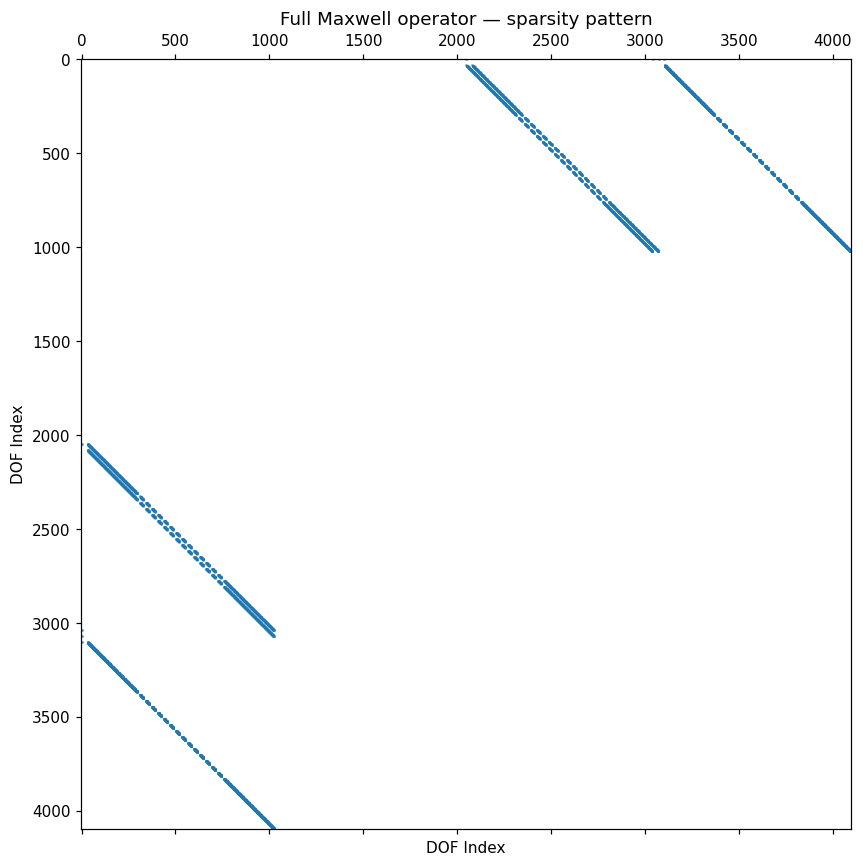

## Field Dynamics Employing Hamiltonian Simulation with GQSP

Our goal is to implement the time-evolution operator $e^{(c/\Delta L)\,A\,t}$, where $A$ is the anti-symmetric Maxwell matrix. We achieve this through **Generalized Quantum Signal Processing (GQSP)** [<a href="#ref-gqsp">4</a>] in three steps.

### 1. From block encoding to walk operator

Suppose $U_A$ is a block encoding of $A/\alpha$ (with $\alpha$ the encoding scale). Since $A$ is anti-symmetric, $H = iA$ is **Hermitian**, so multiplying the block encoding by a global phase of $i$ gives a block encoding of the Hermitian matrix $H/\alpha$. The **walk operator** is then

$$
W = R \cdot (i\,U_A), \qquad R = 2\,|0\rangle\!\langle 0|_{\text{block}}-I,
$$

where $R$ is the reflection about the block-encoding subspace. If $\lambda_k$ are the eigenvalues of $H/\alpha$ (real, with $|\lambda_k| \le 1$), then the walk operator has eigenvalues $e^{\pm i\,\theta_k}$ with $\theta_k = \arccos(\lambda_k)$.

### 2. Jacobi–Anger polynomial approximation

The desired evolution in the eigenbasis is $e^{-i H t} = e^{A t}$. In terms of the walk operator eigenphases:

$$
e^{-i\,\alpha\,t_{\text{eff}}\,\cos\theta}
\quad\text{with}\quad
t_{\text{eff}} = \frac{c\,t}{\Delta L},
$$

where $\alpha\,t_{\text{eff}}$ is the effective evolution parameter. This function is approximated by a truncated **Jacobi–Anger expansion** — a Laurent polynomial in $e^{i\theta}$:

$$
e^{-i\,\alpha\,t_{\text{eff}}\,\cos\theta} \;\approx\; \sum_{d=-D}^{D} c_d \, e^{i\,d\,\theta},
$$

where $D$ (the GQSP degree) is chosen to achieve a target precision $\varepsilon$.
Specifically we approximate a scaled version of the function, to guarantee GQSP phase finding stability.

In [10]:
from classiq.applications.qsp import (
    gqsp_phases,
    poly_jacobi_anger_degree,
    poly_jacobi_anger_exp_cos,
)


@qfunc
def walk_operator(em_state: EMState, block: QArray) -> None:
    # block encode the anti-symmetric evolution operator
    maxwell_operator(em_state, block)

    # apply an i phase to turn the maxwell operator to a Hamiltonian
    phase(pi / 2)

    # reflect about the subspace of the block-encoding
    reflect_about_zero(block)


encoding_scale = 4.0  # pay a factor of 2 for each lcu.


# scale the gqsp polynomial to be below 1 to improve numerical stability
GQSP_SCALE = 0.5
GQSP_EPS = 1e-6


@qfunc
def hamiltonian_simulation(
    em_state: EMState, block: QArray, t: float
):  # evolution time
    effective_time = t * encoding_scale * (c / dL)

    # use the gqsp to turn the walk operator with eigenvalues exp(i*arccos(lambda))
    # to exp(-i*lambda*t).
    gqsp_degree = poly_jacobi_anger_degree(GQSP_EPS, effective_time)
    print(f"GQSP degree: {gqsp_degree}")

    # approximate exp(i*cos(x)*t) by a polynomial sum_d{c_d exp(i*x*d)}
    poly = GQSP_SCALE * poly_jacobi_anger_exp_cos(gqsp_degree, -effective_time)
    negative_power = (len(poly) - 1) // 2  # use a both negative and positive exponents

    # compute the phases for the wanted polynomial
    phases = gqsp_phases(poly)

    gqsp(
        u=lambda: walk_operator(em_state, block[1:]),
        aux=block[0],
        phases=phases,
        negative_power=negative_power,
    )

Next we introduce a utility function that will allow plotting the initial and final fields

In [11]:
def fields_max_abs(vec: np.ndarray | list[float], L: int) -> np.ndarray:
    """
    Return the max absolute value of each field component (Ez, Hx, Hy).
    Useful as a reference scale for ``plot_fields``.
    """
    vec = np.asarray(vec)
    LL = L * L
    components = [vec[0:LL], vec[2 * LL : 3 * LL], vec[3 * LL : 4 * LL]]
    return np.array([np.max(np.abs(comp.real)) for comp in components])


def plot_fields(
    vec: np.ndarray | list[float],
    L: int,
    title: str = "",
    field_vmax: np.ndarray | list[float] | None = None,
) -> None:
    """
    Plot Ez, Hx, Hy from a state vector on an L x L grid.

    Args:
        vec: State vector of length 4*L*L.
        L: Grid size per axis.
        title: Figure title.
        field_vmax: Optional array of 3 normalization values (one per field).
            When provided, the color scale for each field is [-field_vmax[i], field_vmax[i]]
            and no per-field self-normalization is applied. Useful for plotting
            differences on the same scale as a reference solution.
    """
    vec = np.asarray(vec)
    vec = normalize_phase(vec)

    LL = L * L
    components = [vec[0:LL], vec[2 * LL : 3 * LL], vec[3 * LL : 4 * LL]]
    data = [comp.reshape(L, L).real for comp in components]

    if field_vmax is None:
        raw_max = fields_max_abs(vec, L)
        data_max = np.where(raw_max > 0, raw_max, 1.0)
        data = [d / m for d, m in zip(data, data_max)]
        plot_max = np.array([np.max(np.abs(d)) for d in data])
    else:
        field_vmax = np.asarray(field_vmax, dtype=float)
        plot_max = np.where(field_vmax > 0, field_vmax, 1.0)

    names = ("Ez", "Hx", "Hy")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    if title:
        fig.suptitle(title)
    for ind in range(3):
        ax = axes[ind]
        im = ax.imshow(
            data[ind],
            origin="lower",
            aspect="equal",
            vmin=-plot_max[ind],
            vmax=plot_max[ind],
            cmap="twilight",
        )
        ax.set_title(names[ind])
        plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

### Initial State Preparation

We initialize the field as a **2D Gaussian pulse in the electric field $E_z$ only** — the magnetic components start at rest ($H_x = H_y = 0$). On the $E_z$ sites the amplitude is

$$
E_z(x, y) \;\propto\; \exp\!\left(-\frac{(x-\mu)^2 + (y-\mu)^2}{2\sigma^2}\right),
$$

a bump centered at $(\mu, \mu)$ with width $\sigma$. To stay consistent with the **PEC boundary conditions**, the amplitude is forced to zero on the conducting sites — the $x=0$ and $y=0$ edges and every point inside the rectangular obstacle.

The function below evaluates this profile on the lattice; the resulting (real, normalized) amplitudes are then loaded into the `EMState` register by amplitude encoding (`prepare_amplitudes`), which sets up $|\psi(0)\rangle$ for the subsequent time evolution.

In [12]:
def maxwell_2d_initial_state(x: float, y: float, direction: int, field: int) -> float:
    """
    Load a 2D Gaussian state, taking into account the boundary conditions.
    """
    # only Ez (electric field) is nonzero initially
    if direction != 0 or field != 0:
        return 0.0
    # no field on the boundaries
    if x == 0 or y == 0:
        return 0.0
    # no field in the rectangle
    if bottom_x <= x < top_x and bottom_y <= y < top_y:
        return 0.0
    # field in the rest of the grid
    return float(np.exp(-((x - mu) ** 2 + (y - mu) ** 2) / (2 * sigma**2)))


@qfunc
def prepare_initial_state(em_state: Output[EMState]) -> None:
    """
    Prepare the initial state of the electromagnetic field. Load a 2D Gaussian state, taking into account
    the boundary conditions.
    """
    init_amplitudes = lookup_table(
        maxwell_2d_initial_state,
        [em_state.x, em_state.y, em_state.direction, em_state.field],
    )
    plot_fields(init_amplitudes, L, "initial state t=0")
    prepare_amplitudes(init_amplitudes, 0, em_state)

### Run the Full Algorithm

In [13]:
BLOCK_SIZE = 5


@qfunc
def main(em_state: Output[EMState], block: Output[QNum[BLOCK_SIZE]]) -> None:
    allocate(block)

    prepare_initial_state(em_state)
    hamiltonian_simulation(em_state, block, T)

We wrap synthesis and execution in a single helper, `run_simulation`: it builds the model, synthesizes it, and samples the resulting program on a state-vector simulator, filtering for the all-zeros block subspace (the subspace in which the block encoding realizes the desired operator).

In [14]:
def run_simulation(
    main_func,
    backend_name=ClassiqNvidiaBackendNames.SIMULATOR_STATEVECTOR,
    block_name: str | None = "block",
    show: bool = False,
) -> tuple[pd.DataFrame, QuantumProgram]:
    qmod = create_model(
        main_func,
        constraints=Constraints(max_width=1000),
        preferences=Preferences(
            transpilation_option=TranspilationOption.NONE,
            timeout_seconds=10 * 60,
            symbolic_loops=True,
        ),
    )
    print("Synthesizing...")
    qprog = synthesize(qmod, auto_show=show)
    print("Synthesis completed.")
    execution_prefs = ExecutionPreferences(
        num_shots=1,
        backend_preferences=ClassiqBackendPreferences(backend_name=backend_name),
        transpile_to_hardware=TranspilationOption.INTENSIVE,
    )
    print("Starting execution...")
    with ExecutionSession(qprog, execution_preferences=execution_prefs) as es:
        if block_name is not None:
            es.set_measured_state_filter(block_name, lambda state: state == 0)
        res = es.sample()
    print("Execution completed.")

    return res.dataframe, qprog

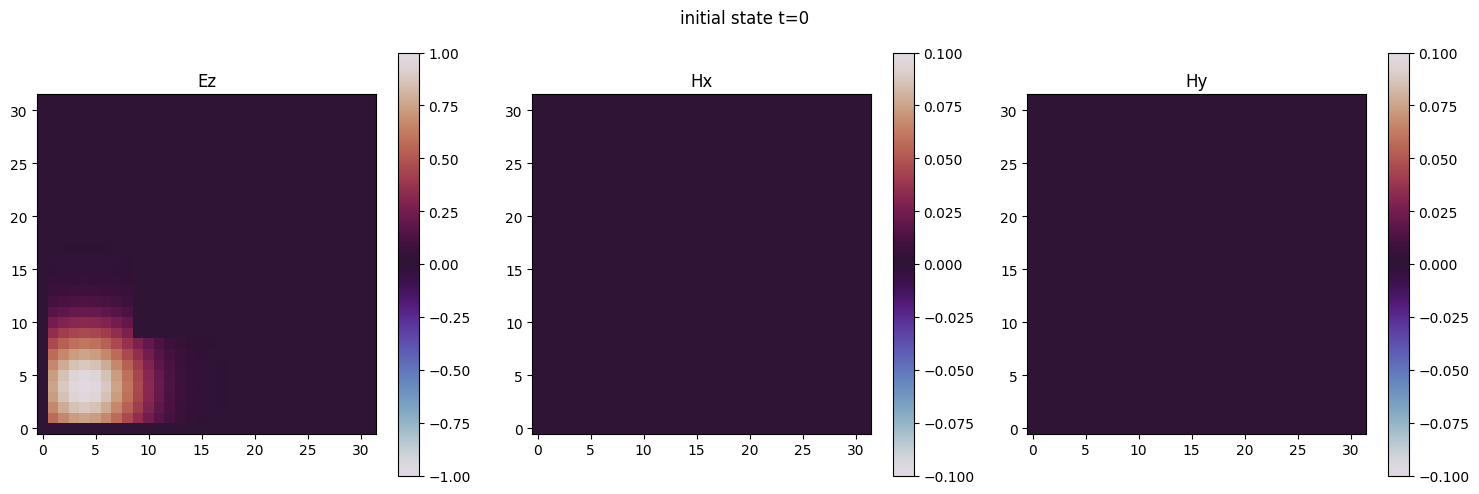

GQSP degree: 686
Synthesizing...
Quantum program link: https://platform.classiq.io/circuit/3ELhKdarLBKxKL8e8UGO0zh6bLo
Synthesis completed.
Starting execution...
Execution completed.


In [15]:
df, qprog = run_simulation(main, show=True)

In [16]:
df.head()

,em_state.x,em_state.y,em_state.direction,em_state.field,block,amplitude,magnitude,phase,probability,bitstring
0,25,25,0,0,0,0.000000-0.037809j,0.04,-0.50π,0.001430,00000110011100100000
1,25,26,0,0,0,0.000001-0.034855j,0.03,-0.50π,0.001215,00000110101100100000
2,26,25,0,0,0,0.000001-0.034852j,0.03,-0.50π,0.001215,00000110011101000000
3,24,26,0,0,0,0.000002-0.031485j,0.03,-0.50π,0.000991,00000110101100000000
4,26,24,0,0,0,0.000002-0.031483j,0.03,-0.50π,0.000991,00000110001101000000


In order to plot the results we first introduce additional utility functions, which extract the dataframe to a numpy array and plot the array. 

In [17]:
def dataframe_to_state_vector(
    df: pd.DataFrame, struct_name: str = "em_state"
) -> tuple[np.ndarray, int]:
    """
    Reconstruct the state vector from a Classiq execution dataframe.

    Filters for block == 0, infers the grid size L, and builds the 4*L*L
    complex amplitude vector using the y*L + x spatial indexing convention.

    Returns:
        (vec, L) where vec has length 4*L*L.
    """
    col_x = f"{struct_name}.x"
    col_y = f"{struct_name}.y"
    col_dir = f"{struct_name}.direction"
    col_field = f"{struct_name}.field"

    df_block0 = df[df["block"] == 0].copy()
    L = int(max(df_block0[col_x].max(), df_block0[col_y].max())) + 1
    LL = L * L
    vec = np.zeros(4 * LL, dtype=complex)
    for _, row in df_block0.iterrows():
        idx = (
            int(row[col_field]) * 2 * LL
            + int(row[col_dir]) * LL
            + int(row[col_y]) * L
            + int(row[col_x])
        )
        vec[idx] = row.amplitude
    return vec, L


def plot_fields_from_dataframe(
    df: pd.DataFrame,
    title: str = "",
    struct_name: str = "em_state",
    field_vmax: np.ndarray | list[float] | None = None,
) -> None:
    """
    Plot Ez, Hx, Hy from a Classiq execution dataframe whose main function
    outputs (em_state: EMState, block: QNum).
    """
    vec, L = dataframe_to_state_vector(df, struct_name)
    plot_fields(vec, L, title, field_vmax)

Finally, the plots of the final fields show the field configuration around the conducting object.

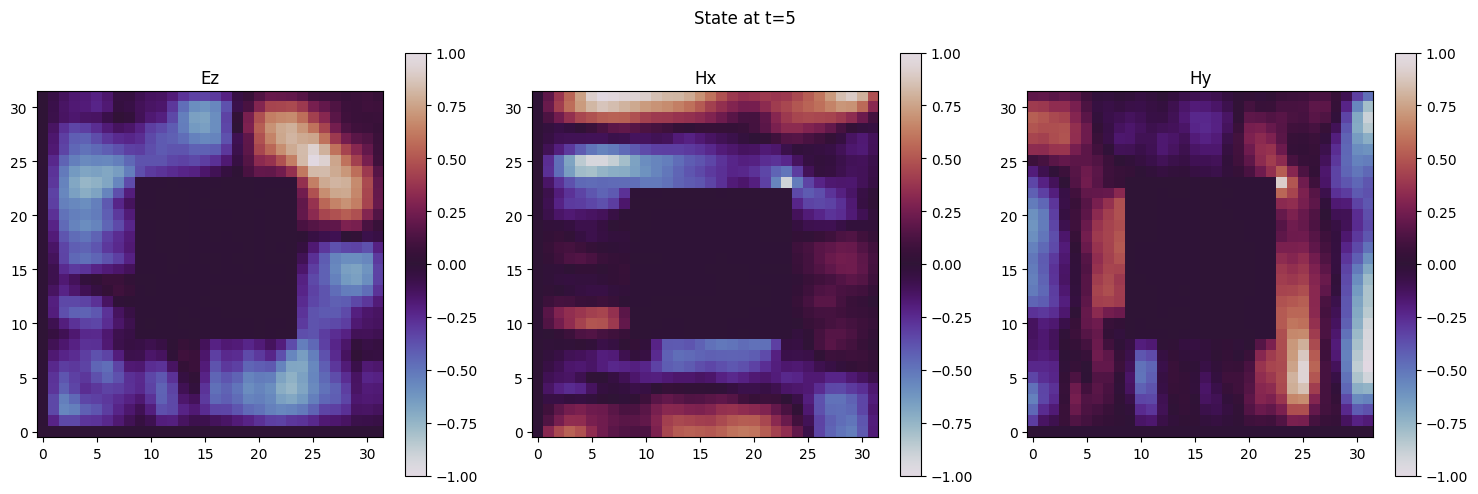

In [18]:
plot_fields_from_dataframe(df, f"State at t={T}")

## Classical Validation

We next benchmark the quantum calculation against a classical solution, employing standard matrix exponentiation. The initial field state is propagated, and the fields at final times are compared.


The classical simulation is performed by the function `classical_maxwell_simulation`, which employs `build_initial_state_vector` to build the initial state field and `build_maxwell_evolution_matrix` to construct the dynamical generator associated with the Maxwell equation.

In [19]:
def build_maxwell_evolution_matrix(
    L: int,
    bottom_x: int,
    top_x: int,
    bottom_y: int,
    top_y: int,
) -> np.ndarray:
    """
    Build the anti-symmetric Maxwell evolution matrix on a square Yee lattice
    of side L, with PEC exterior boundary conditions and a rectangular PEC
    obstacle.

    Args:
        L: Grid side length (must be a power of 2). The lattice is L x L.
        bottom_x, top_x, bottom_y, top_y: Rectangle obstacle bounds.

    Returns:
        The anti-symmetric evolution matrix of shape (4*L*L, 4*L*L).
    """
    LL = L * L

    id_L = np.eye(L, dtype=float)
    zero_LL = np.zeros((LL, LL), dtype=float)

    _grad_b = id_L - np.roll(id_L, 1, 0)
    _grad_f = np.roll(id_L, -1, 0) - id_L

    grad_b_x = np.tensordot(id_L, _grad_b, axes=0).transpose(0, 2, 1, 3).reshape(LL, LL)
    grad_b_y = np.tensordot(_grad_b, id_L, axes=0).transpose(0, 2, 1, 3).reshape(LL, LL)
    grad_f_x = np.tensordot(id_L, _grad_f, axes=0).transpose(0, 2, 1, 3).reshape(LL, LL)
    grad_f_y = np.tensordot(_grad_f, id_L, axes=0).transpose(0, 2, 1, 3).reshape(LL, LL)

    mat_em = np.block(
        [
            [zero_LL, zero_LL, -grad_b_y, grad_b_x],
            [zero_LL, zero_LL, zero_LL, zero_LL],
            [-grad_f_y, zero_LL, zero_LL, zero_LL],
            [grad_f_x, zero_LL, zero_LL, zero_LL],
        ]
    )

    # PEC exterior boundary conditions
    mat_em[1:L, :] = 0
    mat_em[:, 1:L] = 0
    mat_em[L:LL:L, :] = 0
    mat_em[:, L:LL:L] = 0

    # Rectangle obstacle boundary conditions
    if top_x > bottom_x and top_y > bottom_y:
        ins = []
        for iy in range(bottom_y, top_y):
            for ix in range(bottom_x, top_x):
                ins.append(iy * L + ix)
        outs = list(set(range(4 * LL)) - set(ins))
        for in_ in ins:
            for out_ in outs:
                mat_em[in_, out_] = 0
                mat_em[out_, in_] = 0

    assert np.isclose(
        np.sum(np.abs(mat_em + mat_em.T)), 0
    ), "Matrix is not anti-symmetric"

    return mat_em


def build_initial_state_vector(
    L: int,
    initial_state_func: Callable[[float, float, int, int], float],
    normalize: bool = True,
) -> np.ndarray:
    """
    Build the initial state vector by evaluating a callable on every grid point
    of an L x L square lattice.

    The state vector has length 4*L*L, indexed as
    field * 2*LL + direction * LL + y * L + x  (LL = L * L).

    Args:
        L: Grid side length.
        initial_state_func: Callable(x, y, direction, field) -> float.
        normalize: If True, normalize the vector to unit norm.

    Returns:
        The state vector of shape (4*L*L,).
    """
    LL = L * L
    state = np.zeros(4 * LL, dtype=float)
    for field in range(2):
        for direction in range(2):
            for iy in range(L):
                for ix in range(L):
                    idx = field * 2 * LL + direction * LL + iy * L + ix
                    state[idx] = initial_state_func(
                        float(ix), float(iy), direction, field
                    )
    if normalize:
        norm = np.linalg.norm(state)
        if norm > 0:
            state = state / norm
    return state


def classical_maxwell_simulation(
    L: int,
    coeff: float,
    initial_state_func: Callable[[float, float, int, int], float],
    bottom_x: int,
    top_x: int,
    bottom_y: int,
    top_y: int,
) -> np.ndarray:
    """
    Classical reference simulation for 2D Maxwell equations on a square Yee lattice.

    Builds the anti-symmetric evolution matrix with PEC exterior boundary conditions
    and a rectangular PEC obstacle, then computes exp(coeff * A) @ initial_state.

    Args:
        L: Grid side length (must be a power of 2). The lattice is L x L.
        coeff: Evolution coefficient (c * dt / dL).
        initial_state_func: Callable(x, y, direction, field) -> float returning the
            amplitude at each grid point.
        bottom_x, top_x, bottom_y, top_y: Rectangle obstacle bounds.

    Returns:
        The evolved state vector.
    """
    initial_state = build_initial_state_vector(L, initial_state_func)
    mat_em = build_maxwell_evolution_matrix(L, bottom_x, top_x, bottom_y, top_y)
    exp_em = scipy.linalg.expm(coeff * mat_em)
    return exp_em @ initial_state

In [ ]:
# Run the classical simulation
coeff = c * T / dL
classical_vec = classical_maxwell_simulation(
    L,
    coeff,
    maxwell_2d_initial_state,
    bottom_x,
    top_x,
    bottom_y,
    top_y,
)
classical_vec = normalize_phase(classical_vec)

# Compute fidelity
quantum_vec, _ = dataframe_to_state_vector(df)
quantum_vec = normalize_phase(quantum_vec)

fid = fidelity(quantum_vec, classical_vec)
print(f"Fidelity (quantum vs classical): {fid:.6f}")
print(
    f"Encoding Scaling: {np.linalg.norm(quantum_vec)/np.linalg.norm(classical_vec):.6f}",
    f"Expected: {GQSP_SCALE:.6f}",
)
error = 1.0 - fid
print(f"Error in logarithmic scale (log_10(1-fidelity)): {-np.log10(1-fid)}")
assert (
    -np.log10(1 - fid) > 4
), f"The accuracy (-log10(1-fidelity)) between the quantum and classical simulations differed by {-np.log10(1-fid)}"

Fidelity (quantum vs classical): 1.000000
Encoding Scaling: 0.499257 Expected: 0.500000
Error in logarithmic scale (log_10(1-fidelity)): -7.6172263817520545


As the fidelity comparison shows, the quantum and classical calculations agree perfectly.

To visualize this result we plot both fields next to each other, as expected the plots appear identical.

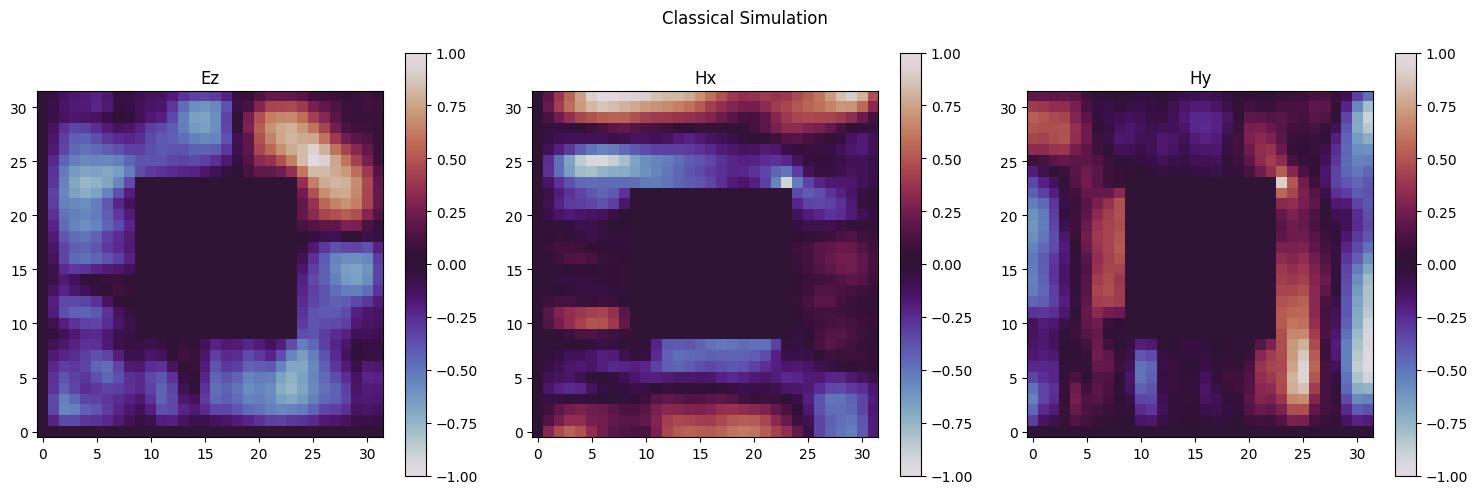

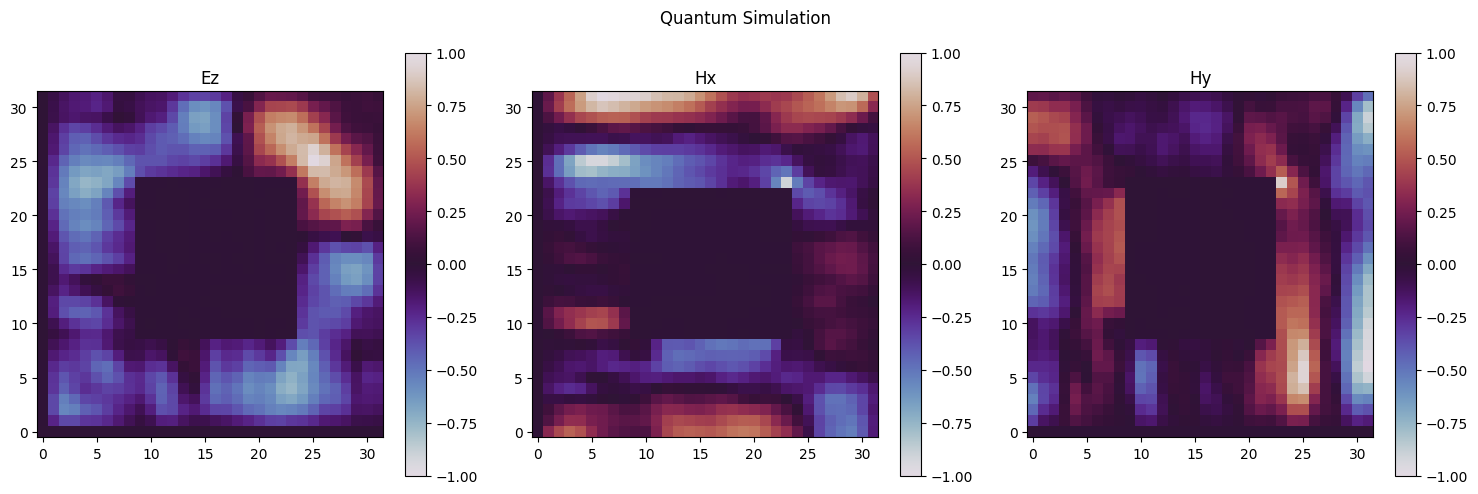

In [21]:
# Plot both results
plot_fields(classical_vec, L, title="Classical Simulation")
plot_fields(quantum_vec, L, title="Quantum Simulation")

## References

<a id='ref-costa'>[1]</a>: [Costa, P. C. S., Jordan, S., and Ostrander, A. *Quantum algorithm for simulating the wave equation.* Physical Review A **99**, 012323 (2019).](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.99.012323)

<a id='ref-suau'>[2]</a>: [Suau, A., Staffelbach, G., and Calandra, H. *Practical quantum computing: solving the wave equation using a quantum approach.* ACM Transactions on Quantum Computing **2**, 1–35 (2021).](https://dl.acm.org/doi/10.1145/3430030)

<a id='ref-yee'>[3]</a>: [Yee, K. *Numerical solution of initial boundary value problems involving Maxwell's equations in isotropic media.* IEEE Transactions on Antennas and Propagation **14**, 302–307 (1966).](https://ieeexplore.ieee.org/document/1138693)

<a id='ref-gqsp'>[4]</a>: [Motlagh, D., and Wiebe, N. *Generalized quantum signal processing.* PRX Quantum **5**, 020368 (2024).](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.5.020368)